# Detecting Malaria cells using Convolutional Neural Network

### Importing Libraries

In [41]:
import json
import numpy as np
import pandas as pd 
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report , accuracy_score
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

In [42]:
infected = os.listdir('cell_images/cell_images/Parasitized/') 
uninfected = os.listdir('cell_images/cell_images/Uninfected/')

### Understanding the Data

In [43]:
data = []
labels = []

for i in infected:
    try:
        image = cv2.imread("cell_images/cell_images/Parasitized/"+i)
        image_array = Image.fromarray(image , 'RGB')
        resize_img = image_array.resize((64 , 64))
        data.append(np.array(resize_img))
        labels.append(1)
        
    except AttributeError:
        print('Error')
    
for u in uninfected:
    try:
        image = cv2.imread("cell_images/cell_images/Uninfected/"+u)
        image_array = Image.fromarray(image , 'RGB')
        resize_img = image_array.resize((64 , 64))
        data.append(np.array(resize_img))
        labels.append(0)
        
    except AttributeError:
        print('Error')

Error
Error


In [44]:
cells = np.array(data)
labels = np.array(labels)

np.save('Cells' , cells)
np.save('Labels' , labels)

In [45]:
print('Cells : {} | labels : {}'.format(cells.shape , labels.shape))

Cells : (27558, 64, 64, 3) | labels : (27558,)


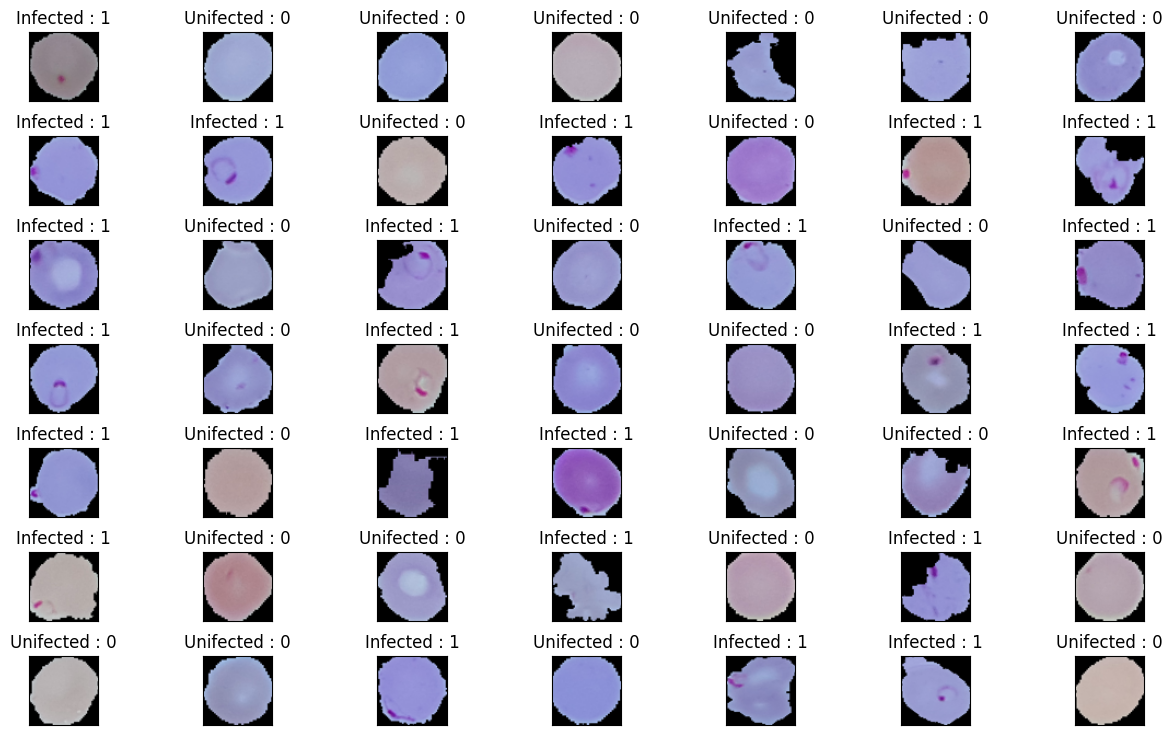

In [46]:
plt.figure(1 , figsize = (15 , 9))
n = 0 
for i in range(49):
    n += 1 
    r = np.random.randint(0 , cells.shape[0] , 1)
    plt.subplot(7 , 7 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    plt.imshow(cells[r[0]])
    plt.title('{} : {}'.format('Infected' if labels[r[0]] == 1 else 'Unifected' ,
                               labels[r[0]]) )
    plt.xticks([]) , plt.yticks([])
    
plt.show()

### Examples of Infected and Uninfected

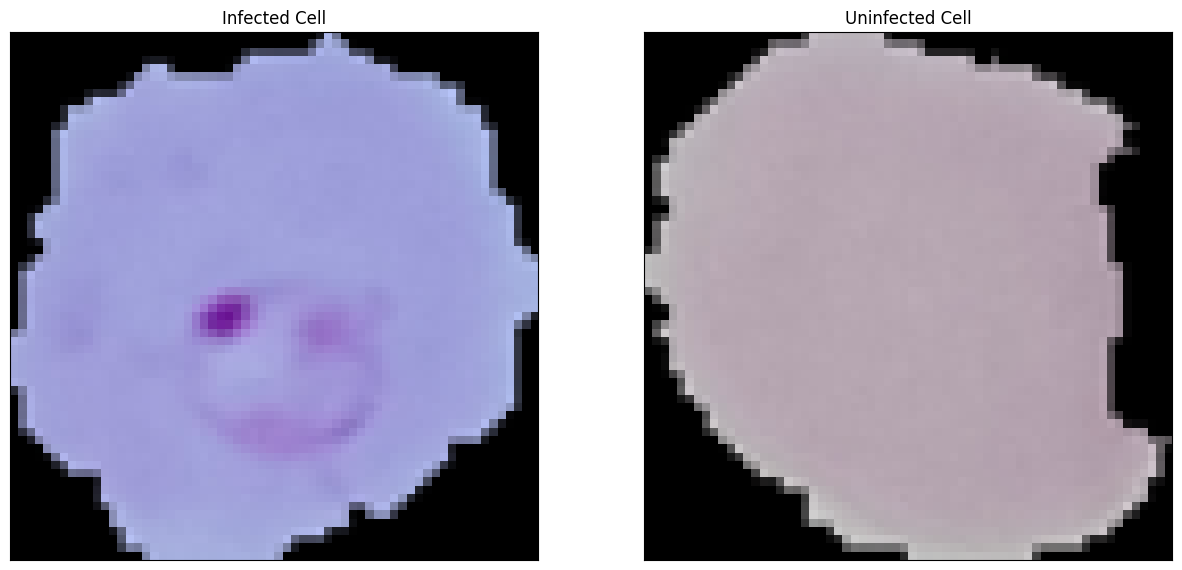

In [47]:
plt.figure(1, figsize = (15 , 7))
plt.subplot(1 , 2 , 1)
plt.imshow(cells[0])
plt.title('Infected Cell')
plt.xticks([]) , plt.yticks([])

plt.subplot(1 , 2 , 2)
plt.imshow(cells[20000])
plt.title('Uninfected Cell')
plt.xticks([]) , plt.yticks([])

plt.show()

In [48]:
n = np.arange(cells.shape[0])
np.random.shuffle(n)
cells = cells[n]
labels = labels[n]

In [49]:
cells = cells.astype(np.float32)
labels = labels.astype(np.int32)
cells = cells/255

### Model Parameters

In [70]:
MODEL_PATH = "malaria_model.keras"

if os.path.exists(MODEL_PATH):
    malaria_detector = tf.keras.models.load_model(MODEL_PATH, compile=True)

    modelLoaded = True
    
    try:
        _ = malaria_detector(tf.zeros((1, 64, 64, 3)))
    except:
        sample_input = malaria_detector.layers[0].input_shape
        _ = malaria_detector(tf.zeros(sample_input))
else:
    modelLoaded = False
    inputs = tf.keras.Input(shape=(64, 64, 3))

    x = tf.keras.layers.Conv2D(32, (3, 3))(inputs)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)
    
    x = tf.keras.layers.Conv2D(64, (3, 3))(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)
    
    x = tf.keras.layers.Conv2D(128, (3, 3))(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)
    
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    
    malaria_detector = tf.keras.Model(inputs=inputs, outputs=outputs, name="malaria_detector")
    

In [71]:
if(modelLoaded != True):
    malaria_detector.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

### Train and Validation Split

In [72]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


train_gen = datagen.flow_from_directory(
    'cell_images/cell_images/',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    'cell_images/cell_images/',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


### Training

In [99]:
epochsCount = 15
if(modelLoaded != True):
    history = malaria_detector.fit(
        train_gen,
        epochs= epochsCount,
        validation_data=val_gen
    )
    with open('training_history.json', 'w') as f:
        json.dump(history.history, f)

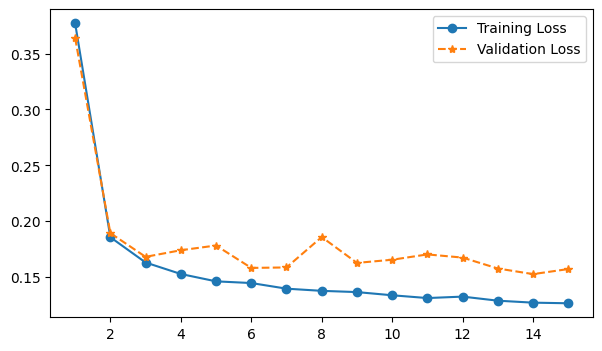

In [137]:
with open('training_history.json', 'r') as f:
    hist = json.load(f)
    
plt.figure(figsize=(7, 4))
ax = plt.axes()
ax.plot(range(1, epochsCount+1), hist["loss"], marker="o", label="Training Loss")
ax.plot(range(1, epochsCount+1), hist["val_loss"], marker="*", ls="--", label="Validation Loss")
ax.legend()
plt.show()

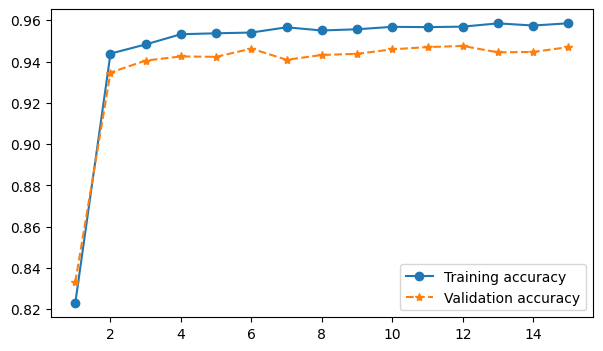

In [138]:
plt.figure(figsize=(7, 4))
ax = plt.axes()
ax.plot(range(1, epochsCount+1), hist["accuracy"], marker="o", label="Training accuracy")
ax.plot(range(1, epochsCount+1), hist["val_accuracy"], marker="*", ls="--", label="Validation accuracy")
ax.legend()
plt.show()

### Evaluation

In [102]:
loss, acc = malaria_detector.evaluate(val_gen)
print(f"Validation Accuracy: {acc*100:.2f}%")

173/173 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.9456 - loss: 0.1544
Validation Accuracy: 94.56%


In [103]:
predictions = malaria_detector.predict(val_gen)
print(predictions[:5])  

173/173 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step
[[7.0638640e-04]
 [3.2078603e-04]
 [1.4640469e-03]
 [5.6173133e-07]
 [8.5444856e-01]]


In [104]:
if(modelLoaded != True):
    malaria_detector.save("malaria_model.keras")

In [105]:
model = tf.keras.models.load_model("malaria_model.keras")
model.export("malaria_saved_model")

INFO:tensorflow:Assets written to: malaria_saved_model\assets


INFO:tensorflow:Assets written to: malaria_saved_model\assets


Saved artifact at 'malaria_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_layer_16')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2290330642640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290330645136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290330642448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290330647248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060616016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060611792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060616208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060615632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060611984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060617168: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [106]:
test_y = val_gen.classes
pred_probs = malaria_detector.predict(val_gen)
classes = (pred_probs > 0.5).astype("int32").flatten()
print("\nClassification Report:\n", classification_report(test_y, classes, target_names=list(val_gen.class_indices.keys())))
print("\nAccuracy: {:.2f}%".format(accuracy_score(test_y, classes) * 100))

173/173 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step

Classification Report:
               precision    recall  f1-score   support

 Parasitized       0.96      0.93      0.94      2755
  Uninfected       0.94      0.96      0.95      2755

    accuracy                           0.95      5510
   macro avg       0.95      0.95      0.95      5510
weighted avg       0.95      0.95      0.95      5510


Accuracy: 94.54%


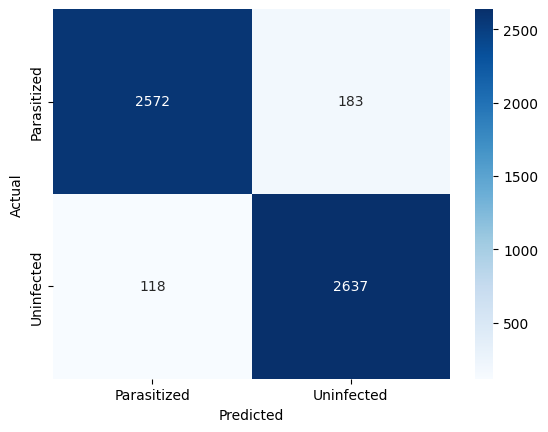

In [107]:
cm = confusion_matrix(test_y, classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=val_gen.class_indices.keys(),
            yticklabels=val_gen.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### GRAD-CAM Model Interpretability

In [108]:
for i, layer in enumerate(malaria_detector.layers):
    print(i, layer.name, layer.__class__.__name__)

0 input_layer_16 InputLayer
1 conv2d_23 Conv2D
2 max_pooling2d_23 MaxPooling2D
3 conv2d_24 Conv2D
4 max_pooling2d_24 MaxPooling2D
5 conv2d_25 Conv2D
6 max_pooling2d_25 MaxPooling2D
7 flatten_9 Flatten
8 dense_18 Dense
9 dropout_7 Dropout
10 dense_19 Dense


In [109]:
last_conv_layer = None
for layer in reversed(malaria_detector.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break
print("Using layer:", last_conv_layer.name)

grad_model = tf.keras.models.Model(
    inputs=malaria_detector.input,
    outputs=[last_conv_layer.output, malaria_detector.output]
)

Using layer: conv2d_25


In [110]:
img_path, label = val_gen.filepaths[3020], val_gen.labels[3020]
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(64, 64))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0
img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

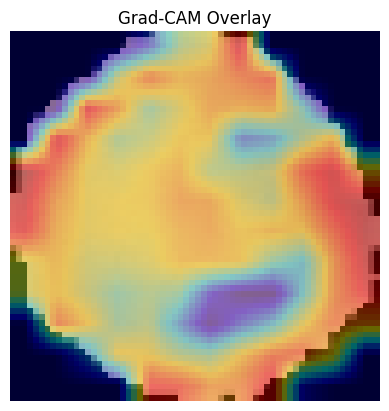

In [111]:
with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    conv_outputs, predictions = grad_model(img_tensor)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)


if grads is None:
    malaria_detector.compile()  
    conv_outputs, predictions = grad_model(img_tensor)
    with tf.GradientTape() as tape:
        tape.watch(conv_outputs)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)



pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]
heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

if isinstance(heatmap, tf.Tensor):
    heatmap = heatmap.numpy()
heatmap = cv2.resize(heatmap, (64, 64))


img = cv2.imread(img_path)
img = cv2.resize(img, (64, 64))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.show()

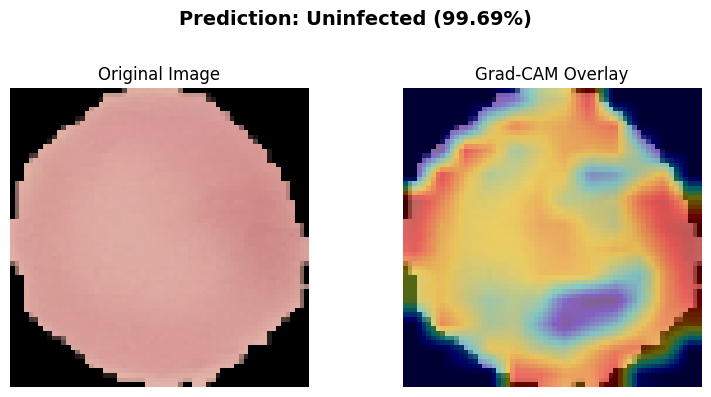

In [112]:
pred = malaria_detector.predict(img_array, verbose=0)[0][0]
pred_class = "Uninfected" if pred > 0.5 else "Infected"
confidence = pred * 100 if pred > 0.5 else (1 - pred) * 100

original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
original_img = cv2.resize(original_img, (64, 64))

plt.figure(figsize=(8, 4))
plt.suptitle(f"Prediction: {pred_class} ({confidence:.2f}%)", fontsize=14, fontweight='bold')

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


### Quantization of the Model

In [113]:
model = tf.keras.models.load_model("malaria_model.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_quant_model = converter.convert()

with open("malaria_model_quantized.tflite", "wb") as f:
    f.write(tflite_quant_model)

print("Quantized model saved")


INFO:tensorflow:Assets written to: C:\Users\Aindril\AppData\Local\Temp\tmp0e1_4cvj\assets


INFO:tensorflow:Assets written to: C:\Users\Aindril\AppData\Local\Temp\tmp0e1_4cvj\assets


Saved artifact at 'C:\Users\Aindril\AppData\Local\Temp\tmp0e1_4cvj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_layer_16')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2290334809360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060621776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060622352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060619472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060619856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060623120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060616592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060616400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060621008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290060622160: TensorSpec(shape=(), dtype=tf.resource, name=None)
Quant

In [114]:
before = os.path.getsize("malaria_model.keras") / 1024
after = os.path.getsize("malaria_model_quantized.tflite") / 1024
print(f"Before: {before:.1f} KB | After quantization: {after:.1f} KB")

Before: 8057.9 KB | After quantization: 679.7 KB


### Evaluation of Quantized Model

In [115]:
interpreter = tf.lite.Interpreter(model_path="malaria_model_quantized.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_true = []
y_pred = []

for i, (x_batch, y_batch) in enumerate(val_gen):
    for x, y in zip(x_batch, y_batch):
        x = np.expand_dims(x, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], x)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        pred = (output > 0.5).astype(int).flatten()[0]
        y_pred.append(pred)
        y_true.append(int(y))
    if i > 200:
        break

print(f"Quantized model accuracy on sample validation data: {100*np.mean(np.array(y_pred)==np.array(y_true)):.2f}%\n")

# Classification report
print(classification_report(y_true, y_pred, target_names=['Uninfected', 'Infected']))


C:\Users\Aindril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized model accuracy on sample validation data: 95.06%

              precision    recall  f1-score   support

  Uninfected       0.97      0.94      0.96      3654
    Infected       0.93      0.96      0.94      2784

    accuracy                           0.95      6438
   macro avg       0.95      0.95      0.95      6438
weighted avg       0.95      0.95      0.95      6438

